<a href="https://colab.research.google.com/github/jaehyeon0420/agent_tutorial/blob/master/rag_basic_example/rag_basic_multimodal_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 본 파일은 텍스트, 차트, 이미지, 표로 이루어진 2026년 경제 전망.pdf로 구축한 RAG 프로젝트입니다.
#### - 멀티턴, 멀티쿼리는 포함되지 않으며 답변은 오직 텍스트로 출력됩니다.
#### - 사용자 질문 시, 답변에 출처(이미지 번호) 포함됩니다.
#### - 문서를 인용할 수 없는 경우, 답변이 제한됩니다.
#### - 각 슬라이드 캡셔닝 이미지, XML 기반으로 생성된 LLM 분석 결과와
#### 고정 텍스트 사이즈로 청킹된 청크를 각각의 컬렉션에 저장합니다.
#### 이후, 두 가지 전처리 방식의 검색 성능을 평가 및 비교합니다.


In [ ]:
pip install pymupdf openai gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 33.8 MB/s eta 0:00:00


In [ ]:
import os
import re
import numpy as np
import base64
import requests
from tqdm import tqdm
from PIL import Image
import fitz
import io
import pandas as pd
import random
import ast
from openai import OpenAI
import json
import fitz
import xml.etree.ElementTree as ET
import xml.dom.minidom as minidom
from google.colab import userdata

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get('OPEN_AI_KEY')

In [ ]:
client = OpenAI()

## 슬라이드 -> 이미지로 저장

- 각 슬라이드를 캡셔닝하여 이미지로 저장합니다.

In [ ]:
# 이미지를 base64 형식으로 인코딩하는 함수
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# 이미지가 다단인지 확인하는 함수
def is_two_column(img_array, threshold=240, column_width=0.1):
    height, width = img_array.shape[:2]
    center_start = int(width * (0.5 - column_width/2))
    center_end = int(width * (0.5 + column_width/2))

    center_region = img_array[:, center_start:center_end]

    # 이미지가 컬러라면 RGB를 그레이스케일로 변환
    if len(img_array.shape) == 3:
        center_region = np.mean(center_region, axis=2)

    vertical_projection = np.mean(center_region, axis=1)
    white_ratio = np.mean(vertical_projection > threshold)

    return white_ratio > 0.9  # 중심 부분이 90% 이상 흰색일 때 다단으로 간주

In [ ]:
# PNG 이미지를 최적화하는 함수
def optimize_png(img):
    img_buffer = io.BytesIO()
    img.save(img_buffer, format='PNG', optimize=True, compress_level=6)
    optimized_img = Image.open(img_buffer)
    return optimized_img

# PDF 파일을 처리하여 각 페이지를 이미지로 저장하는 함수
def process_pdf(pdf_path, output_folder, dpi=300):
    doc = fitz.open(pdf_path)
    os.makedirs(output_folder, exist_ok=True)

    for page_num in range(len(doc)):
        page = doc[page_num]
        zoom = dpi / 72
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat, alpha=False)

        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        img_array = np.array(img)

        # 이미지 최적화 후 저장
        optimize_png(img).save(os.path.join(output_folder, f'page_{page_num+1}.png'))

    doc.close()

In [ ]:
# 사용 예시: PDF 파일을 이미지로 변환
pdf_path = '2026_경제_전망.pdf'
output_folder = '.'
process_pdf(pdf_path, output_folder)

In [ ]:
files = os.listdir()

In [ ]:
# 현재 경로에 존재하는 파일들
print(files)

['.config', 'page_53.png', 'page_37.png', 'page_7.png', 'page_32.png', 'page_46.png', 'page_25.png', 'page_51.png', 'page_27.png', 'page_26.png', 'page_31.png', 'page_41.png', 'page_55.png', 'page_44.png', 'page_21.png', 'page_2.png', 'page_50.png', 'page_16.png', 'page_11.png', 'page_22.png', 'page_30.png', 'page_40.png', 'page_35.png', 'page_39.png', 'page_17.png', 'page_14.png', 'page_38.png', 'page_54.png', 'page_36.png', 'page_19.png', 'page_34.png', 'page_24.png', 'page_23.png', 'page_8.png', 'page_18.png', 'page_28.png', 'page_1.png', 'page_15.png', 'page_13.png', 'page_52.png', 'page_43.png', 'page_47.png', 'page_48.png', '2026_경제_전망.pdf', 'page_4.png', 'page_29.png', 'page_56.png', 'page_10.png', 'page_9.png', 'page_33.png', 'page_49.png', 'page_3.png', 'page_20.png', 'page_42.png', 'page_12.png', 'page_45.png', 'page_5.png', 'page_6.png', 'sample_data']


## 슬라이드 -> xml로 저장

- 각 슬라이드 내용을 xml 형식으로 저장합니다.

In [ ]:
def has_meaningful_content(text):
    """텍스트가 의미있는 내용을 포함하는지 확인"""
    if not text:
        return False

    # HTML 태그 제거
    text = re.sub(r'<[^>]+>', '', text)
    # 특수문자 디코딩
    text = text.replace('&lt;', '<').replace('&gt;', '>').replace('&amp;', '&')
    # 공백, 특수문자 제거
    text = re.sub(r'[\s\t\n\r\f\v]+', '', text)
    # div, page 같은 일반적인 태그 관련 단어 제거
    text = re.sub(r'(div|page|style|width|height|pt)', '', text, flags=re.IGNORECASE)

    # 숫자와 단위 제거
    text = re.sub(r'\d+\.?\d*\s*(pt|px|em|rem|%)', '', text)

    # 남은 텍스트가 있는지 확인
    return bool(text.strip())

def extract_content_with_fallback(page):
    """여러 방법을 순차적으로 시도하여 의미있는 내용 추출"""
    content = None
    error_messages = []

    # 1. 기본 텍스트 추출 시도
    try:
        text = page.get_text("text")
        if text and has_meaningful_content(text):
            root = ET.Element("page")
            text_elem = ET.SubElement(root, "text")
            text_elem.text = text.strip()
            return ET.tostring(root, encoding='utf-8').decode('utf-8'), None
    except Exception as e:
        error_messages.append(f"기본 텍스트 추출 실패: {str(e)}")

    # 2. 블록 단위 추출 시도
    try:
        blocks = page.get_text("blocks")
        meaningful_blocks = []
        for block in blocks:
            if has_meaningful_content(block[4]):
                meaningful_blocks.append(block[4].strip())

        if meaningful_blocks:
            root = ET.Element("page")
            blocks_elem = ET.SubElement(root, "blocks")
            for block_text in meaningful_blocks:
                block_elem = ET.SubElement(blocks_elem, "block")
                block_elem.text = block_text
            return ET.tostring(root, encoding='utf-8').decode('utf-8'), None
    except Exception as e:
        error_messages.append(f"블록 추출 실패: {str(e)}")

    # 3. 단어 단위 추출 시도
    try:
        words = page.get_text("words")
        meaningful_words = []
        for word in words:
            if has_meaningful_content(word[4]):
                meaningful_words.append(word[4].strip())

        if meaningful_words:
            root = ET.Element("page")
            words_elem = ET.SubElement(root, "words")
            for word_text in meaningful_words:
                word_elem = ET.SubElement(words_elem, "word")
                word_elem.text = word_text
            return ET.tostring(root, encoding='utf-8').decode('utf-8'), None
    except Exception as e:
        error_messages.append(f"단어 추출 실패: {str(e)}")

    # 4. rawdict 시도
    try:
        raw_dict = page.get_text("rawdict")
        if "blocks" in raw_dict:
            meaningful_text = []
            for block in raw_dict["blocks"]:
                if "lines" in block:
                    for line in block["lines"]:
                        if "spans" in line:
                            for span in line["spans"]:
                                if has_meaningful_content(span.get("text", "")):
                                    meaningful_text.append(span["text"].strip())

            if meaningful_text:
                root = ET.Element("page")
                text_elem = ET.SubElement(root, "text")
                text_elem.text = " ".join(meaningful_text)
                return ET.tostring(root, encoding='utf-8').decode('utf-8'), None
    except Exception as e:
        error_messages.append(f"rawdict 추출 실패: {str(e)}")

    # 모든 방법이 실패했거나 의미있는 내용이 없는 경우 None 반환
    return None, "\n".join(error_messages)

def convert_pdf_to_xml(pdf_path, output_folder):
    """PDF를 XML로 변환하는 메인 함수"""
    if not os.path.exists(pdf_path):
        print(f"PDF 파일을 찾을 수 없습니다: {pdf_path}")
        return

    os.makedirs(output_folder, exist_ok=True)

    print(f"PDF 파일 열기: {pdf_path}")
    doc = fitz.open(pdf_path)

    for page_num in range(len(doc)):
        print(f"페이지 {page_num + 1}/{len(doc)} 처리 중...")
        page = doc[page_num]

        content, errors = extract_content_with_fallback(page)
        output_file = os.path.join(output_folder, f"page_{page_num+1:02d}.xml")

        if content:
            print(f"XML 파일 저장 중: {output_file}")
            with open(output_file, "w", encoding="utf-8") as f:
                f.write(content)
            print(f"페이지 {page_num + 1} 처리 완료")
        else:
            print(f"페이지 {page_num + 1}에서 추출된 의미있는 내용이 없습니다.")
            # 빈 내용일 경우 파일 생성하지 않음
            if os.path.exists(output_file):
                os.remove(output_file)

    doc.close()
    print("모든 페이지 처리 완료")

In [ ]:
pdf_path = '2026_경제_전망.pdf'
output_folder = '.'
convert_pdf_to_xml(pdf_path, output_folder)

PDF 파일 열기: 2026_경제_전망.pdf
페이지 1/56 처리 중...
XML 파일 저장 중: ./page_01.xml
페이지 1 처리 완료
페이지 2/56 처리 중...
XML 파일 저장 중: ./page_02.xml
페이지 2 처리 완료
페이지 3/56 처리 중...
XML 파일 저장 중: ./page_03.xml
페이지 3 처리 완료
페이지 4/56 처리 중...
XML 파일 저장 중: ./page_04.xml
페이지 4 처리 완료
페이지 5/56 처리 중...
XML 파일 저장 중: ./page_05.xml
페이지 5 처리 완료
페이지 6/56 처리 중...
XML 파일 저장 중: ./page_06.xml
페이지 6 처리 완료
페이지 7/56 처리 중...
XML 파일 저장 중: ./page_07.xml
페이지 7 처리 완료
페이지 8/56 처리 중...
XML 파일 저장 중: ./page_08.xml
페이지 8 처리 완료
페이지 9/56 처리 중...
XML 파일 저장 중: ./page_09.xml
페이지 9 처리 완료
페이지 10/56 처리 중...
XML 파일 저장 중: ./page_10.xml
페이지 10 처리 완료
페이지 11/56 처리 중...
XML 파일 저장 중: ./page_11.xml
페이지 11 처리 완료
페이지 12/56 처리 중...
XML 파일 저장 중: ./page_12.xml
페이지 12 처리 완료
페이지 13/56 처리 중...
XML 파일 저장 중: ./page_13.xml
페이지 13 처리 완료
페이지 14/56 처리 중...
XML 파일 저장 중: ./page_14.xml
페이지 14 처리 완료
페이지 15/56 처리 중...
XML 파일 저장 중: ./page_15.xml
페이지 15 처리 완료
페이지 16/56 처리 중...
XML 파일 저장 중: ./page_16.xml
페이지 16 처리 완료
페이지 17/56 처리 중...
XML 파일 저장 중: ./page_17.xml
페이지 17 처리 완료
페이지 18

In [ ]:
# 디렉토리에서 매칭되는 XML과 PNG 파일들을 가져오는 함수
def get_matched_files(directory):
    files = os.listdir(directory)

    xml_files = {}
    png_files = {}

    # XML과 PNG 파일들을 분류
    for file in files:
        match = re.match(r'page_(\d+)\.(xml|png)$', file)
        if match:
            number = int(match.group(1))
            extension = match.group(2)
            if extension == 'xml':
                xml_files[number] = file
            elif extension == 'png':
                png_files[number] = file

    # 모든 페이지 번호를 결합하여 매칭
    all_numbers = set(xml_files.keys()).union(set(png_files.keys()))

    matched_files = []
    for number in sorted(all_numbers):
        xml_path = os.path.join(directory, xml_files[number]) if number in xml_files else 'no xml'
        png_path = os.path.join(directory, png_files[number]) if number in png_files else 'no png'
        matched_files.append((xml_path, png_path))

    return matched_files

In [ ]:
%pwd

'/content'

- 각 슬라이드별 이미지와 XML을 매핑 시킵니다.

In [ ]:
# 사용 예시: 매칭된 파일 가져오기
directory = r'/content'
files = get_matched_files(directory)

In [ ]:
files

[('/content/page_01.xml', '/content/page_1.png'),
 ('/content/page_02.xml', '/content/page_2.png'),
 ('/content/page_03.xml', '/content/page_3.png'),
 ('/content/page_04.xml', '/content/page_4.png'),
 ('/content/page_05.xml', '/content/page_5.png'),
 ('/content/page_06.xml', '/content/page_6.png'),
 ('/content/page_07.xml', '/content/page_7.png'),
 ('/content/page_08.xml', '/content/page_8.png'),
 ('/content/page_09.xml', '/content/page_9.png'),
 ('/content/page_10.xml', '/content/page_10.png'),
 ('/content/page_11.xml', '/content/page_11.png'),
 ('/content/page_12.xml', '/content/page_12.png'),
 ('/content/page_13.xml', '/content/page_13.png'),
 ('/content/page_14.xml', '/content/page_14.png'),
 ('/content/page_15.xml', '/content/page_15.png'),
 ('/content/page_16.xml', '/content/page_16.png'),
 ('/content/page_17.xml', '/content/page_17.png'),
 ('/content/page_18.xml', '/content/page_18.png'),
 ('/content/page_19.xml', '/content/page_19.png'),
 ('/content/page_20.xml', '/content/page

## GPT 호출

#### - 1. 전체 이미지와 추출된 XML을 GPT에 전달하여 해석 결과를 응답 받습니다.
#### - 2. 해석 결과와 전체 이미지 정보를 매핑하여 관리합니다.

In [ ]:
# XML이 없는 경우 사용할 시스템 프롬프트
# 현재 경제 전망.pdf는 XML 파일이 모두 존재하자만 없는 경우 대비
no_xml_system_prompt = '''당신이 해석할 이미지는 경제 전망 보고서입니다.
1. 중요한 내용이므로 요약하지말고 문법에 신경쓰면서 보이는 그대로 작성해주세요.
2. 내용을 임의로 바꾸지 마세요. 그리고 보이는 모든 내용을 다 적으십시오.
3. 단, 테이블은 풀어서 평문 또는 나열식으로 작성해주세요. 이미지에 없는 말은 적지마세요.
4. 테이블 풀어서 평문 또는 나열식으로 작성할 때 다른 행과 열이랑 헷갈리지 않게 값마다 잘 구분해서 적어주세요.
5. 테이블 해석할 때 통합셀들이 존재하니 구조를 잘 해석해서 작성해주시기 바랍니다. 어떤 게 어떤 것의 하위 내용인지를 명확히 하십시오
6. 당신의 의견은 궁금하지 않습니다. 해드렸습니다. 완성했습니다. 이런 표현도 적지마십시오. 이미지에 있는 내용만 적으십시오.
7. 만약 다단으로 구성되어져 있다면 좌측 테이블부터 먼저 작성하고 우측 테이블을 작성하십시오.

자, 당신이 모든 내용을 빠트리지 않으면서 테이블은 구조를 잘 해석해서 작성해주는 것을 믿습니다.
'''

In [ ]:
# XML이 있는 경우 사용할 시스템 프롬프트
system_prompt = '''당신이 해석할 이미지는 경제 전망 보고서입니다.
1. 중요한 내용이므로 요약하지말고 문법에 신경쓰면서 보이는 그대로 작성해주세요.
2. 내용을 임의로 바꾸지 마세요. 그리고 보이는 모든 내용을 다 적으십시오.
3. 단, 테이블은 풀어서 평문 또는 나열식으로 작성해주세요. 이미지에 없는 말은 적지마세요.
4. 테이블 풀어서 평문 또는 나열식으로 작성할 때 다른 행과 열이랑 헷갈리지 않게 값마다 잘 구분해서 적어주세요.
5. 테이블 해석할 때 통합셀들이 존재하니 구조를 잘 해석해서 작성해주시기 바랍니다. 어떤 게 어떤 것의 하위 내용인지를 명확히 하십시오
6. 당신의 의견은 궁금하지 않습니다. 해드렸습니다. 완성했습니다. 이런 표현도 적지마십시오. 이미지에 있는 내용만 적으십시오.
7. 만약 다단으로 구성되어져 있다면 좌측 테이블부터 먼저 작성하고 우측 테이블을 작성하십시오.
8. 당신에게 당신이 해석할 파일을 xml로 변경한 내용도 드리겠습니다. 페이지 해석할 때 참고하세요.
9. xml에 있는 텍스트는 반드시 해당 페이지에 존재한다는 겁니다. xml에 있는 텍스트를 빠트리지 마십시오.

자 당신이 헷갈리지 않도록 xml도 드렸습니다. 이미지를 더 잘 해석할 거라 믿습니다.
'''

In [ ]:
%%time
# 이미지와 XML 파일을 사용하여 AI 모델에 요청을 보내는 코드
result_lst = []
for file in tqdm(files):
    image_path = file[1]

    # 이미지를 base64 형식으로 인코딩
    base64_image = encode_image(image_path)

    if file[0] == 'no xml':
        print(file[1], '은 xml이 없습니다.')
        prompt = no_xml_system_prompt
    else:
        with open(file[0], 'r', encoding='utf-8') as f:
            xml_content = f.read()
        prompt = system_prompt + xml_content + '\n시작!'

    response = client.responses.create(
    model="gpt-4.1-mini",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": prompt},
            {
                "type": "input_image",
                "image_url": f"data:image/jpeg;base64,{base64_image}",
            },
        ],
    }],
    )
    result_lst.append(response.output_text)

100%|██████████| 56/56 [11:10<00:00, 11.98s/it]

CPU times: user 2.04 s, sys: 183 ms, total: 2.22 s
Wall time: 11min 10s


In [ ]:
# 결과 매핑하여 csv 파일로 저장

import pandas as pd

# 데이터 구성
xml_paths = [f[0] for f in files]
img_paths = [f[1] for f in files]

# 데이터프레임 생성
df = pd.DataFrame({
    'xml_path': xml_paths,
    'image_path': img_paths,
    'content': result_lst  # 분석 결과 문자열 리스트
})

# CSV 파일로 저장 (인코딩은 한글 깨짐 방지를 위해 utf-8-sig 권장)
output_path = 'rag_basic_multimodal_1_processed_results.csv'
df.to_csv(output_path, index=True, index_label='id', encoding='utf-8-sig')

#### 1. 개인 토큰 비용을 아끼기 위해 저장한 csv 파일에서 읽어와 처리합니다.
#### 2. 매번 동일한 LLM 분석 결과 데이터로 검색 하여 전처리 이전과 이후를 비교하기 위함입니다.

In [ ]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv('rag_basic_multimodal_1_processed_results.csv', index_col='id')

# xml_path와 image_path를 튜플 리스트로 변환
files = list(zip(df['xml_path'], df['image_path']))

# content를 문자열 리스트로 변환
result_lst = df['content'].tolist()


# 결과 확인 (샘플 출력)
print(f"복원된 files 개수: {len(files)}")
print(f"첫 번째 튜플 샘플: {files[0]}")
print(f"첫 번째 content 샘플: {result_lst[0][:30]}...")

복원된 files 개수: 56
첫 번째 튜플 샘플: ('/content/page_01.xml', '/content/page_1.png')
첫 번째 content 샘플: 2026년 2월 27일 (금)
KB국민은행 자본시장그룹...


## RAG

#### - 2026_경제_전망.pdf 파일 내 각 슬라이드는 모두 독립적이므로 별도 overlap 하거나, Q&A 형태의 합성 데이터는 제작하지 않습니다.

In [ ]:
pip install -U chromadb

In [ ]:
import chromadb
from openai import OpenAI
from chromadb.utils import embedding_functions
from google.colab import userdata

In [ ]:
documents_content = []
metadatas = []
ids = []

for i, (f, r) in enumerate(zip(files, result_lst)):
    page_name = f[1].split('/')[-1] # 파일명만 추출 (예: page_1.png)

    # ChromaDB에 직접 넣을 데이터들
    documents_content.append(r) # 실제 분석 텍스트
    metadatas.append({"source": page_name, "xml_path": f[0]}) # 메타데이터
    ids.append(f"id_{i}") # 고유 ID (필수)

In [ ]:
documents_content[1]

'Executive Summary\n\nMacro: 세계 경제는 순항 중\n• 미국 트럼프 정부의 관세 부과에도 세계 경제는 양호한 확장 국면 지속 - 각국 정부의 재정 확대, 중앙은행 완화 기조, 글로벌 공급망 다변화\n• 미국 경제는 25년 2.2%에서 26년 2.4%로 개선 - 낮은 실업률과 견고한 소비지출, 민간의 AI 투자 지속, 정부의 감세 등 재정 지원 등\n• 유로존과 일본은 재고 조정과 기저효과로 소폭 성장 둔화, 중국은 정부의 재정 확대에도 소비와 투자 등 내수 성장 약화\n• 한국 경제는 반도체가 이끄는 성장, 정부의 추가 재정지출 확대로 소비 지원, 반도체 호조에 생산 및 수출 양호 (26년 2.0% 성장 전망)\n\n금리: 수급 불안과 통화정책 전환 우려 확산 (’26년 미국 10년 3.80~4.40%, 한국 10년 3.20~3.70%)\n• 미국, 연방정부 셧다운 여파에도 주요 경제지표 호조를 보이며 정책금리 인하 시점 지연, 3분기 3.25%로 금리인하 사이클 종료 전망\n• 신임 연준 의장인 케빈 워시, 정책금리 인하와 대차대조표 축소를 동시에 추구 - 장기물 중심 금리 상승 요인이나 점진적 시행 예상\n• 한국, 기준금리 인하 사이클 사실상 종료, 과도한 인상 기대 되돌려지면서 국고채 금리 높은 레벨대 박스권 등락 전망\n• 일본, 정부 압력에도 임금 상승 압력에 금리 인상 사이클 지속, 다카이치 내각의 확장적 재정정책에 장기물 중심 상승추세 이어질 전망\n\n환율, 트럼프 리스크에 노출된 미국 달러화, 구조적 변화에 놓인 한국 원화 (2026년 1,380~1,485원)\n• 2026년 미국 달러화는 상반기 연준 금리 인하 기대에 약세, 하반기에는 AI 기반 생산성 개선으로 제한적 반등 시도 예상\n• 다만, 트럼프 정책 리스크에 따른 달러 자산 신뢰 약화, 미국 정부의 환율 정책 등 달러화에 대한 약세 리스크 상존\n• 유로화는 弱달러 반사 이익에 강세, 엔화는 확장 재정부담으로 완만한 약세, 위안화는 정부 주도의 절상 용인으로

In [ ]:
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=userdata.get('OPEN_AI_KEY'),
    model_name="text-embedding-3-large"
)

# 3. ChromaDB 클라이언트 및 컬렉션 설정
client_1 = chromadb.PersistentClient(path="./chroma_db")
processed_collection = client_1.get_or_create_collection(
    name="processed_collection",
    embedding_function=openai_ef
)

# 4. 데이터 적재 (중요: documents는 반드시 문자열 리스트여야 함)
processed_collection.add(
    ids=ids,
    documents=documents_content,
    metadatas=metadatas
)

open_ai_client = OpenAI(api_key=userdata.get('OPEN_AI_KEY'))

print(f"적재 완료: 총 {processed_collection.count()}개의 페이지가 저장되었습니다.")

적재 완료: 총 56개의 페이지가 저장되었습니다.


In [ ]:
def context_pair(all_results) :
    context_parts = []
    for i, doc in enumerate(all_results):
        source = doc['metadata'].get('source', '알 수 없음')
        # 컨텍스트에 메타데이터를 포함시켜 LLM이 인용할 수 있게 함
        context_parts.append(f"[문서 {i+1} / 출처: {source}]\n{doc['page_content']}")

    return  "\n\n".join(context_parts)

def get_llm_response(context: str, query: str) :

    system_prompt = """당신은 경제 전망에 대해 설명해주는 챗봇 '머니'입니다.

    배재현 개발자가 만들었습니다. 주어진 검색 결과를 바탕으로 답변하세요.

    1. 당신은 오직 위에서 제공된 참고 자료에 있는 사실 정보에만 근거해 사용자 질문에 답변해야 하며, 절대 지어내거나 허구의 정보를 포함해서는 안 됩니다.
    2. 만약 사용자의 질문을 명확히 하는 것이 답변에 도움이 된다면, 질문을 시도할 수 있습니다.
    3. 만약 참고 자료에 있는 정보로 질문에 충분히 답변할 수 없다면, 다음의 문장을 그대로 답변으로 사용해야 합니다: "죄송합니다. 참고 자료에는 요청하신 질문에 답변할 만한 충분한 정보가 없네요.".
    4. 만약 답변에 참고 자료의 내용을 인용했다면, 답변에 사용한 문장이나 문단 끝마다 해당 참고 자료의 source를 반드시 추가해야 합니다. source 값은 참고 자료에서 가져오며, 두 개의 대괄호로 감싸야 합니다. 예시: [[page_21.png]], [[page_29.png]]
    5. 반드시 한국어로 1인칭 시점에서 정확하고 엄격한 스타일로 답변해야 하며, 사실을 기반으로 상세히 설명해야 합니다.
    """

    user_prompt = f"""
    ## 참고 정보(Context)
    {context}

    ## 사용자 질문
    {query}

    ## 답변:"""

    response = open_ai_client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0
            )

    return response.choices[0].message.content.strip()


def retrieve(query: str, num_docs: int = 5) -> list[dict]:
    all_results = []
    seen_contents = set()

    # 쿼리 임베딩
    query_vector = openai_ef.embed_query(query)[0]

    # ChromaDB 검색
    search_results = processed_collection.query(
        query_embeddings=[query_vector],
        n_results=num_docs
    )

    # 결과 파싱 및 중복 제거
    for i in range(len(search_results['documents'][0])):
        content = search_results['documents'][0][i]
        metadata = search_results['metadatas'][0][i] or {}

        # 중복 검사 및 결과 병합
        if content not in seen_contents:
            seen_contents.add(content)
            # 메타데이터에 어떤 쿼리로 검색되었는지 기록 (디버깅용)
            metadata["source_query"] = query

            all_results.append({
                "page_content": content,
                "metadata": metadata
            })

    print(f"[+] 최종 {len(all_results)}개의 고유 문서 추출 완료.")

    # 하나의 문자열로 병합
    context = context_pair(all_results)

    res_msg = get_llm_response(context, query)

    return res_msg

In [ ]:
res_msg = retrieve(query="중국 경제 전망 어때?")
res_msg

[+] 최종 5개의 고유 문서 추출 완료.


'중국 경제는 2025년 연간 성장률이 5.0%로 정부 목표에 부합할 것으로 전망되고 있습니다. 소비와 투자 등은 다소 부진하지만, 수출과 제조업이 성장의 주요 견인 역할을 할 것으로 보입니다. 특히, 중국의 PMI 제조업 및 서비스업 모두 확장 국면을 지속하고 있으며, 서비스업의 업황이 제조업보다 양호한 상황입니다[[문서 1 / 출처: page_13.png]].\n\n미중 갈등이 다소 완화되면서, 중국의 수출 공급망 변화로 인해 미국에 대한 수출 감소의 영향이 크지 않을 것으로 예상됩니다. 2025년 대미 수출 비중은 11.1%로, 2019년의 16.7%에 비해 큰 폭으로 축소될 것으로 보이며, 대신 아세안(베트남 등) 및 남미 지역으로의 수출 비중이 확대될 것입니다[[문서 1 / 출처: page_13.png]].\n\n또한, 중국 정부는 재정지출을 확대하고 있지만, 소비와 투자 등 내수 지표는 다소 둔화되고 있습니다. 공급망 변화에 따른 급격한 조정 가능성은 제한적일 것으로 보입니다[[문서 2 / 출처: page_4.png]].\n\n결론적으로, 중국 경제는 전반적으로 안정적인 성장세를 유지할 것으로 보이며, 수출과 제조업이 주요 성장 동력으로 작용할 것입니다.'

In [ ]:
res_msg = retrieve(query="일본 장기금리 급등에 정부의 국채 순이자 지급 급증")
res_msg

[+] 최종 5개의 고유 문서 추출 완료.


'일본의 장기금리 급등은 정부의 국채 순이자 지급을 크게 증가시키고 있습니다. OECD의 추정에 따르면, 2026년 일본 정부의 국채 순이자 지급 규모는 2.4조 엔에 이를 것으로 예상되며, 2027년에는 8.45조 엔으로 급증할 것으로 보입니다[[page_17.png]]. \n\n장기금리의 상승은 재정 부담을 확대하고, 금융기관의 손실 및 가계와 기업의 자본 비용 증가를 초래합니다. 특히, 부채가 과다한 정부, 가계, 기업은 이러한 상황에서 더욱 큰 위험에 처하게 됩니다[[page_17.png]]. \n\n일본의 장기금리 상승은 확대 재정정책과 기준금리 인상의 결합으로 인해 더욱 가속화되고 있으며, 이는 재정적자 확대 우려와 함께 장기물 중심으로 금리가 상승하는 추세를 보이고 있습니다[[page_35.png]]. \n\n결론적으로, 일본의 장기금리 급등은 정부의 국채 순이자 지급을 급증시키고 있으며, 이는 재정적자와 금리 인상 사이클의 지속으로 인해 더욱 심화될 전망입니다.'

In [ ]:
res_msg = retrieve(query="원달러 환율 전망에 대해서 알려주세요")
res_msg

[+] 최종 5개의 고유 문서 추출 완료.


"2026년 원달러 환율 전망에 대해 설명드리겠습니다. 2026년에는 원화가 조정 이후 재차 약세로 전환될 것으로 예상되며, 연평균 환율은 약 1,420원으로 전망됩니다. 이는 미국 달러화의 약세에도 불구하고 원화의 펀더멘털 문제로 인해 '뉴 노멀' 구간에 진입할 것으로 보입니다[[문서 1 / 출처: page_38.png]].\n\n상반기에는 글로벌 약달러 환경과 일본 엔화의 강세에 동조하며 원화가 일시적으로 강세를 보일 것으로 예상됩니다. 이는 미국 연준의 금리 인하 기대와 달러 신뢰 약화로 인해 달러/원 환율이 하락 압력을 받을 것으로 보입니다[[문서 4 / 출처: page_51.png]].\n\n하반기에는 미국 달러화의 반등과 일본의 재정 부담이 부각되면서 원화에 대한 대외 상방 압력이 다시 확대될 것으로 예상됩니다. 이로 인해 원화의 가치가 비대칭적으로 변동할 가능성이 있으며, 한미 성장 격차 확대와 해외 투자 지속으로 원화 약세 기조가 고착될 것으로 보입니다[[문서 1 / 출처: page_38.png]], [[문서 3 / 출처: page_54.png]].\n\n결론적으로, 2026년 원달러 환율은 상반기에는 일시적인 강세를 보일 수 있으나, 하반기에는 다시 약세로 돌아서며 연평균 1,420원대에 머무를 것으로 전망됩니다[[문서 3 / 출처: page_54.png]]."

In [ ]:
res_msg = retrieve(query="오늘 점심 메뉴 추천해주세요")
res_msg

[+] 최종 5개의 고유 문서 추출 완료.


'죄송합니다. 참고 자료에는 요청하신 질문에 답변할 만한 충분한 정보가 없네요.'

In [ ]:
pip install gradio

In [ ]:
import gradio as gr

# 인터페이스를 생성.
with gr.Blocks() as demo:
    chatbot = gr.Chatbot(label="경제전망 챗봇") # 챗봇 응답
    msg = gr.Textbox(label="질문해주세요!")  # 하단의 채팅창의 레이블
    clear = gr.Button("대화 초기화")  # 대화 초기화 버튼

    # 챗봇의 답변을 처리하는 함수
    def respond(message, chat_history):
      bot_message = retrieve(message)

      # 채팅 기록에 사용자의 메시지와 봇의 응답을 추가.
      chat_history.append((message, bot_message))
      return "", chat_history

    # 사용자의 입력을 제출(submit)하면 respond 함수가 호출.
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    # '초기화' 버튼을 클릭하면 채팅 기록을 초기화.
    clear.click(lambda: None, None, chatbot, queue=False)

# 인터페이스 실행.
demo.launch(debug=True)

/tmp/ipykernel_6383/2932434649.py:5: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(label="경제전망 챗봇") # 챗봇 응답
/tmp/ipykernel_6383/2932434649.py:5: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(label="경제전망 챗봇") # 챗봇 응답


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b3a670d6e6f3bc811e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[+] 최종 5개의 고유 문서 추출 완료.
[+] 최종 5개의 고유 문서 추출 완료.
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b3a670d6e6f3bc811e.gradio.live


## 검색 성능 평가

### 위 전처리된 문서와 전처리 이전의 문서 검색 성능을 비교하기 위해, 원본 문서 텍스트를 size 기준으로 청킹합니다.

In [ ]:
# OpenAI API, Vector DB, PDF 처리, 토큰 계산
!pip install -U openai chromadb pypdf

In [ ]:
import os
import json
from typing import List, Dict

# OpenAI API 관련
from openai import OpenAI

# 벡터 DB 관련
import chromadb
from chromadb.utils import embedding_functions

# PDF 로딩 관련
from pypdf import PdfReader

- PDF 모든 텍스트를 병합합니다.

In [ ]:
def load_pdf(file_path: str) -> str:
    reader = PdfReader(file_path)
    full_text = ""

    for page in reader.pages:
        # 페이지 텍스트 추출 (None 반환 대비)
        text = page.extract_text()
        if text:
            full_text += text + "\n"

    return full_text

pdf_text = load_pdf("2026_경제_전망.pdf")

- 텍스트를 오버랩 기준으로 청킹하여 문자열 리스트를 생성합니다.

In [ ]:
def chunk_text(text: str, chunk_size: int, chunk_overlap: int) -> List[str]:
    chunks = []

    # 시작 지점을 overlap만큼 이동하며 반복
    start = 0

    while start < len(text):
        # 종료 지점 계산
        end = start + chunk_size

        # 청킹
        chunk = text[start:end]
        chunks.append(chunk)

        # 다음 시작 지점 = 현재 종료 지점 - 오버랩
        start += (chunk_size - chunk_overlap)

        # 무한 루프 방지 (오버랩이 청크 사이즈보다 크거나 같을 경우)
        if chunk_size <= chunk_overlap:
            break

    return chunks

# 설정 값 예시
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100

chunks = chunk_text(pdf_text, CHUNK_SIZE, CHUNK_OVERLAP)

In [ ]:
import uuid
from google.colab import userdata

openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=userdata.get('OPEN_AI_KEY'),
    model_name="text-embedding-3-large"
)

client_2 = chromadb.PersistentClient(path="./chroma_db")
none_processed_collection = client_2.get_or_create_collection(
    name="none_processed_collection",
    embedding_function=openai_ef
)


In [ ]:
def add_chunks_to_db(chunks: list[str], metadata_list: list[dict] = None):
    """
    동일한 청크를 OpenAI와 BGE-M3 모델로 각각 임베딩하여 별도 컬렉션에 적재합니다.
    """

    # 동일한 청크는 두 DB에서 같은 ID를 가지게 하여 추후 비교 평가를 용이하게 합니다.
    ids = [str(uuid.uuid4()) for _ in range(len(chunks))]
    if metadata_list is None:
        metadata_list = [{"source": "pdf_document"} for _ in range(len(chunks))]

    none_processed_collection.add(
        ids=ids,
        documents=chunks,
        metadatas=metadata_list
    )

    print(f"\n[성공] 총 {len(chunks)}개의 청크가 벡터 DB에 저장되었습니다.")

In [ ]:
add_chunks_to_db(chunks)


[성공] 총 101개의 청크가 벡터 DB에 저장되었습니다.


- 평가를 위해, 각 문서별로 질문을 2개씩 생성합니다.

In [ ]:
import os
import re
import time
from tqdm import tqdm
from openai import OpenAI

open_ai_client = OpenAI(api_key=userdata.get('OPEN_AI_KEY'))

def generate_evaluation_dataset(chunks, num_questions_per_doc=2):
    """
    각 청크(Chunk)에 대한 질문을 생성하고 평가용 데이터셋 구조를 반환합니다.

    Args:
        chunks: 청크 리스트
        num_questions_per_doc: 청크 당 생성할 질문 수

    Returns:
        all_queries: {질문_ID: 질문_텍스트}
        corpus: {문서_ID: 문서_텍스트}
        relevant_docs: {질문_ID: [관련_문서_ID]}
    """

    all_queries = {}
    corpus = {}
    relevant_docs = {}

    prompt_template = """
    당신은 질문 생성 전문가입니다. 아래 제공된 [맥락]을 읽고, 해당 내용에 대해 답할 수 있는 질문을 {num}개 생성하세요.

    [맥락]
    {context}

    [지침]
    - 질문은 반드시 한국어로 작성하세요.
    - 각 질문은 독립적이어야 하며, 본문 없이 질문만 읽어도 의미가 전달되어야 합니다.
    - '위 본문에 따르면', '제시된 글에서'와 같은 표현은 절대 사용하지 마세요.
    - 질문만 작성하고 답안이나 해설은 포함하지 마세요.
    - 아래 형식과 같이 번호를 나열하여 생성하세요:
    1. 질문 내용
    2. 질문 내용
    """

    for i, chunk in enumerate(tqdm(chunks, desc="질문 생성 중")):
        time.sleep(1.0)

        # 입력 형식이 문자열인지 딕셔너리인지 확인하여 처리
        if isinstance(chunk, dict):
            text = chunk.get('text', '')
            doc_id = chunk.get('id', f"doc_{i}")
        else:
            text = chunk
            doc_id = f"doc_{i}"

        corpus[doc_id] = text

        try:
            # LLM 호출 (온도는 0으로 설정하여 일관성 유지)
            response = open_ai_client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": "당신은 질문 생성 도우미입니다. 제공된 정보 기반으로 질문을 생성하세요."},
                    {"role": "user", "content": prompt_template.format(context=text, num=num_questions_per_doc)}
                ],
                temperature=0.7
            )

            # 응답 텍스트 파싱
            raw_output = response.choices[0].message.content.strip()
            lines = raw_output.split("\n")

            q_count = 0
            for line in lines:
                # 숫자. 형식을 제거하고 실제 질문 텍스트만 추출
                clean_question = re.sub(r"^\d+[\.\)\s]+", "", line).strip()

                if clean_question and len(clean_question) > 5:
                    query_id = f"q_{doc_id}_{q_count}"
                    all_queries[query_id] = clean_question
                    relevant_docs[query_id] = [doc_id]
                    q_count += 1

                    if q_count >= num_questions_per_doc:
                        break

        except Exception as e:
            print(f"\n[오류] 문서 {doc_id} 처리 중 오류 발생: {e}")

    return all_queries, corpus, relevant_docs

- queries : 'q_문서번호_질문번호'를 key로, '생성된 질문'을 value로 가지는 딕셔너리
- corpus : 'doc_문서번호'를 key로, 문서를 value로 가지는 딕셔너리
- relevant_docs : 'q_문서번호_질문번호'를 key로, 'doc_문서번호'를 value로 가지는 딕셔너리

In [ ]:
n_queries, n_corpus, n_relevant_docs = generate_evaluation_dataset(chunks)

질문 생성 중: 100%|██████████| 101/101 [04:19<00:00,  2.57s/it]


In [ ]:
p_queries, p_corpus, p_relevant_docs = generate_evaluation_dataset(documents_content)

질문 생성 중: 100%|██████████| 56/56 [02:28<00:00,  2.66s/it]


In [ ]:
from typing import Any, Optional

#  리트리버 Wrapper
class Retriever:
    """
    이미 구축된 ChromaDB 컬렉션을 사용하여 벡터 검색을 수행하는 클래스입니다.
    """
    def __init__(self, collection, client, model_name="text-embedding-3-large", k: int = 5):
        self.collection = collection
        self.client = client
        self.model_name = model_name
        self.k = k

    def invoke(self, query: str, k: Optional[int] = None) -> List[Dict[str, Any]]:
        target_k = k if k else self.k

        # 1. 쿼리 임베딩
        query_vector = self.client.embeddings.create(
            input=[query.replace("\n", " ")],
            model=self.model_name
        ).data[0].embedding

        # 2. ChromaDB 검색
        results = self.collection.query(
            query_embeddings=[query_vector],
            n_results=target_k
        )

        # 3. 데이터 포맷 통일
        docs = []
        for i in range(len(results['documents'][0])):
            docs.append({
                "page_content": results['documents'][0][i],
                "metadata": results['metadatas'][0][i] or {}
            })
        return docs

In [ ]:
# 리트리버 객체 생성

n_retriever = Retriever(collection=none_processed_collection, client=open_ai_client, k=5)
p_retriever = Retriever(collection=processed_collection, client=open_ai_client, k=5)


In [ ]:
# 문서 ID와 내용 매핑 만들기 (평가 함수 외부에서 한 번만 실행)
n_documents = [
   {"page_content": chunk, "metadata": {"id": f"doc_{i}"}}
    for i, chunk in enumerate(chunks)
]

p_documents = [
   {"page_content": doc, "metadata": {"id": f"doc_{i}"}}
    for i, doc in enumerate(documents_content)
]


n_document_mapping = {}
for i, doc in enumerate(n_documents):
    doc_id = doc['metadata']['id']
    n_document_mapping[doc['page_content']] = doc_id

p_document_mapping = {}
for i, doc in enumerate(p_documents):
    doc_id = doc['metadata']['id']
    p_document_mapping[doc['page_content']] = doc_id

# 내용으로 문서 ID 찾는 함수
def get_doc_id_by_content(content, gb):
    """내용으로 문서 ID 찾기 (완전 일치 또는 부분 일치)"""

    if gb == "n" :
      # 완전 일치 확인
      if content in n_document_mapping:
          return n_document_mapping[content]

      # 부분 일치 확인 (내용이 더 길거나 짧을 수 있음)
      for doc_content, doc_id in n_document_mapping.items():
          if content in doc_content or doc_content in content:
              return doc_id

    elif gb == "p" :
      # 완전 일치 확인
      if content in p_document_mapping:
          return p_document_mapping[content]

      # 부분 일치 확인 (내용이 더 길거나 짧을 수 있음)
      for doc_content, doc_id in p_document_mapping.items():
          if content in doc_content or doc_content in content:
              return doc_id
    return None

#### 1. Accuracy@k
Accuracy@k는 각 질문에 대한 검색 결과 K개에서 정답의 포함여부를 평가하는 지표입니다.
결과 K개에서 1개라도 정답이 포함되었다면 '성공'으로 간주됩니다.

예시) 질문에 대해 상위 5개의 검색 결과가 나왔다고 가정합니다.
- 질문1 : [**정답**, 오답, 오답, 오답, 오답] => 정답 포함되어 성공
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => 정답 포함되어 성공
- 질문3 : [오답, 오답, 오답, 오답, 오답] => 정답 미포함이므로 실패

성공인 경우 1로, 실패인 경우 0으로 계산합니다.

Accuracy@5 = (1+1+0) / 3 = 0.666... => 66.6%

Accuracy@5 = 66.6% 해석 : 전체 질문 중 약 66.6%에서 상위 5개의 결과 안에 정답이 하나라도 포함되어 있음.

In [ ]:
def calculate_accuracy_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    상위 k개 결과 안에 정답이 포함되어 있는지 여부를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0 또는 1 (정답이 상위 k개 안에 없으면 0, 있으면 1)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 상위 k개 중 정답이 하나라도 있는지 확인
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            return 1.0

    return 0.0

#### 2. Precision@k
Precision@k는 각 질문에 대한 검색 결과 K개에서 정답 갯수를 평가하는 지표입니다.
결과 K개 중, 정답이 차지하는 비율을 측정합니다.

예시) 질문에 대해 상위 5개의 검색 결과가 나왔다고 가정합니다.
- 질문1 : [**정답**, 오답, 오답, 오답, 오답] => (1/5) = 0.2
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => (1/5) = 0.2
- 질문3 : [오답, 오답, 오답, 오답, 오답] => (0/5) = 0

Precision@5 = (0.2+0.2+0) / 3 = 0.1333... => 13.3%

Precision@5 = 13.3% 해석 : 전체 질문에 대하여, 정답의 비율

In [ ]:
def calculate_precision_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    상위 k개 결과 중 정답의 비율을 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (상위 k개 중 정답의 비율)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    if not top_k_docs:
        return 0.0

    # 상위 k개 중 정답의 개수
    relevant_count = 0
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_count += 1

    return relevant_count / len(top_k_docs)

#### 3. Recall@k
Recall@k는 검색 결과가 얼마나 포괄적으로 정답을 포함하고 있는지를 평가합니다.
전체 정답 중, 검색 결과 상위 k개 안에 포함된 정답의 비율을 나타냅니다.

상위 K개에 포함된 정답의 갯수를 전체 정답 갯수로 나눕니다.
각 질문당 실제 정답이 하나씩만 있는 경우 Accuracy와 Recall 값은 동일합니다.

예시) 질문에 대해 실제 정답 갯수가 2개라고 가정합니다.
- 질문1 : [**정답**, 오답, **정답**, 오답, 오답] => (2/2) = 1.0
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => (1/2) = 0.5
- 질문3 : [오답, 오답, 오답, 오답, 오답] => (0/2) = 0

Recall@5 = (1.0+0.5+0) / 3 = 0.5... => 50.0%

Recall@5 = 50% 해석 : 전체 정답 중 50%가 상위 5개 결과에 포함되었음.
- 높을수록 검색 시스템이 관련 문서를 빠짐없이 찾아낸다
- 중요 정보를 놓치지 않아야 하는 상황에서 중요한 지표
- 모든 관련 정보를 찾는 능력을 평가하는 지표

In [ ]:
def calculate_recall_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    전체 정답 중 상위 k개에 포함된 정답의 비율을 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (전체 정답 중 상위 k개에 포함된 비율)
    """
    if not relevant_docs:
        return 0.0

    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 상위 k개에 포함된 정답의 개수 계산
    relevant_found = 0
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_found += 1

    return relevant_found / len(relevant_docs)

### 4. MRR@k (Mean Reciprocal Rank - 첫 번째 정답 순위의 역수)

MRR@k는 첫 번째 정답이 등장한 순위의 역수를 계산합니다.
첫 정답이 상위에 있을수록 높은 점수를 부여합니다.

계산 방법:
- 정답이 1위에 있으면 MRR = 1.0
- 정답이 2위에 있으면 MRR = 0.5
- 정답이 3위에 있으면 MRR = 0.33...
- 상위 k개 안에 정답이 없으면 MRR = 0

해석 예시:
- MRR@10 = 0.5: 첫 번째 정답이 평균적으로 2위에 등장한다는 의미
- 사용자가 정답을 얼마나 "빨리" 찾을 수 있는지를 평가하는 지표

실제 예시:
질문에 대해 상위 10개의 검색 결과가 다음과 같다고 가정합니다.
- 질문 1: [**정답**, 오답, 오답, ...] Reciprocal Rank = 1/1 = 1.0
- 질문 2: [오답, **정답**, 오답, ...] Reciprocal Rank = 1/2 = 0.5
- 질문 3: [오답, 오답, **정답**, ...] Reciprocal Rank = 1/3 = 0.33
- 질문 4: [오답, 오답, 오답, ...] Reciprocal Rank = 0 (정답이 상위 10위 안에 없음)

평균 MRR@10 = (1.0 + 0.5 + 0.33 + 0)/4 = 0.458

In [ ]:
def calculate_mrr_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    Mean Reciprocal Rank를 계산합니다 (첫 번째 정답 순위의 역수).

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (첫 번째 정답 순위의 역수, 없으면 0)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 첫 번째 정답 순위 찾기
    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            return 1.0 / (i + 1)  # 0부터 시작하므로 +1

    return 0.0

### 5. NDCG@k (Normalized Discounted Cumulative Gain)

NDCG@k는 검색 결과의 관련성과 순위를 모두 고려하는 메트릭입니다.  
관련 문서가 높은 순위에 배치될수록 높은 점수를 부여합니다.

계산 방법:
1. DCG(Discounted Cumulative Gain) 계산:
   - 검색된 각 문서가 정답인지 확인합니다.
   - 정답인 문서에 대해, 위치에 따라 할인된 점수를 부여합니다(log₂(rank+1)로 나눔).
   - 이 점수들의 합을 구합니다.

2. Ideal DCG 계산:
   - 모든 정답 문서가 상위에 있는 이상적인 경우의 DCG를 계산합니다.

3. NDCG = DCG / Ideal DCG (0~1 사이의 값)

해석 예시:
- NDCG@10 = 0.85: 검색 결과가 이상적인 순서에 85% 근접함
- 정답의 순위 분포를 고려하는 종합적인 메트릭

실제 예시:
- 질문 1: [정답, 정답, 오답] → NDCG = 1.0 (정답이 모두 상위에 있음)
- 질문 2: [오답, 정답, 오답] → NDCG ≈ 0.63 (정답이 두 번째 위치에 있음)
- 질문 3: [오답, 오답, 정답] → NDCG ≈ 0.39 (정답이 세 번째 위치에 있음)

평균 NDCG@3 = (1.0 + 0.63 + 0.39)/3 ≈ 0.673

In [ ]:
import numpy as np

def calculate_ndcg_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    NDCG@k (Normalized Discounted Cumulative Gain)를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (1에 가까울수록 이상적인 검색 결과)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 실제 DCG 계산
    dcg = 0
    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            # i는 0부터 시작하므로 i+1이 실제 순위
            dcg += 1.0 / np.log2(i + 2)  # log_2(rank + 1)

    # 이상적인 DCG 계산 (모든 관련 문서가 상위에 있을 경우)
    ideal_dcg = 0
    for i in range(min(len(relevant_docs), k)):
        ideal_dcg += 1.0 / np.log2(i + 2)

    # NDCG 계산
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

### 6. MAP@k (Mean Average Precision)

MAP@k는 각 정답을 찾을 때마다의 Precision 값을 계산하여 평균을 낸 값입니다.
검색 결과의 전반적인 정확도와 일관성을 평가합니다.

계산 방법:
1. 각 정답 발견 시 해당 위치까지의 Precision 계산
2. 이 Precision 값들의 평균 산출

해석 예시:
- MAP@100 = 0.818: 상위 100개 내에서 정답을 찾을 때마다 계산된 Precision의 평균이 0.818
- 검색 시스템의 전반적인 일관성을 측정하는 종합적인 지표

실제 예시:
상위 5개 결과가 [**정답**, 오답, **정답**, 오답, **정답**]인 경우:
- 첫 번째 정답 발견 시 Precision = 1/1 = 1.0
- 두 번째 정답 발견 시 Precision = 2/3 = 0.67
- 세 번째 정답 발견 시 Precision = 3/5 = 0.6
- MAP@5 = (1.0 + 0.67 + 0.6) / 3 = 0.76

In [ ]:
def calculate_map_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    MAP@k (Mean Average Precision)를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (각 정답 발견 시 precision의 평균)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 각 정답을 찾을 때마다의 Precision 계산
    precisions = []
    relevant_count = 0

    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_count += 1
            precisions.append(relevant_count / (i + 1))

    # MAP 계산
    return sum(precisions) / len(relevant_docs) if precisions and relevant_docs else 0.0

In [ ]:
# 모든 메트릭을 계산하는 함수
def calculate_all_metrics(retrieved_docs, relevant_docs, k_values=[1, 3, 5, 10], gb=""):
    """
    모든 평가 메트릭을 계산하는 함수

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k_values: 평가할 k 값들의 리스트

    Returns:
        모든 메트릭 결과를 담은 딕셔너리
    """
    metrics = {}

    # 각 k 값에 대해 모든 메트릭 계산
    for k in k_values:
        metrics[f'Accuracy@{k}'] = calculate_accuracy_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'Precision@{k}'] = calculate_precision_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'Recall@{k}'] = calculate_recall_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'MRR@{k}'] = calculate_mrr_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'NDCG@{k}'] = calculate_ndcg_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'MAP@{k}'] = calculate_map_at_k(retrieved_docs, relevant_docs, k, gb)

    return metrics

In [ ]:
import pandas as pd

def evaluate_retriever(retriever, queries, relevant_docs, name="", k_values=[1, 3, 5, 10], gb=""):
    """
    각 리트리버의 성능을 평가하는 함수

    Args:
        retriever: 평가할 리트리버 객체
        queries: 질문 ID를 키로, 질문 텍스트를 값으로 하는 딕셔너리
        relevant_docs: 질문 ID를 키로, 관련 문서 ID 집합을 값으로 하는 딕셔너리
        name: 리트리버 이름 (출력용)
        k_values: 평가할 k 값들의 리스트

    Returns:
        평균 메트릭 딕셔너리
    """
    print(f"\n{name} 리트리버 평가 중...")
    results = []

    # 일부 질문만 평가 (속도 향상을 위해)
    # 실제 평가에서는 모든 질문을 사용하는 것이 더 정확합니다
    sample_queries = dict(list(queries.items())[:500])

    # 각 질문에 대해 리트리버 평가
    for query_id, query_text in tqdm(sample_queries.items()):
        # 리트리버로 문서 검색
        retrieved_docs = retriever.invoke(query_text)

        # 관련 문서 ID 가져오기
        expected_ids = relevant_docs.get(query_id, set())

        # 검색 결과 평가 (모든 메트릭 계산)
        metrics = calculate_all_metrics(retrieved_docs, expected_ids, k_values, gb)

        # 결과 저장
        result = {
            'query_id': query_id,
            'query': query_text,
            **metrics
        }
        results.append(result)

    # 데이터프레임으로 변환
    df_results = pd.DataFrame(results)

    # 평균 메트릭 계산
    metrics_columns = [col for col in df_results.columns if any(col.startswith(prefix) for prefix in
                                                              ['Accuracy', 'Precision', 'Recall', 'MRR', 'NDCG', 'MAP'])]
    avg_metrics = df_results[metrics_columns].mean().to_dict()

    # 주요 메트릭 출력
    print(f"{name} 리트리버 평가 결과 (평균):")
    for k in sorted(k_values):
        print(f"  k={k} 결과:")
        for metric_prefix in ['Accuracy', 'Precision', 'Recall', 'MRR', 'NDCG', 'MAP']:
            metric_key = f"{metric_prefix}@{k}"
            if metric_key in avg_metrics:
                print(f"    {metric_key}: {avg_metrics[metric_key]:.4f}")

    return avg_metrics

In [ ]:
print("\n리트리버 평가 시작...")
n_metrics = evaluate_retriever(n_retriever, n_queries, n_relevant_docs, "전처리 이전", [1, 3, 5, 10], "n")
p_metrics = evaluate_retriever(p_retriever, p_queries, p_relevant_docs, "전처리 이후", [1, 3, 5, 10], "p")


리트리버 평가 시작...

전처리 이전 리트리버 평가 중...


100%|██████████| 202/202 [00:41<00:00,  4.84it/s]


전처리 이전 리트리버 평가 결과 (평균):
  k=1 결과:
    Accuracy@1: 0.3861
    Precision@1: 0.3861
    Recall@1: 0.3861
    MRR@1: 0.3861
    NDCG@1: 0.3861
    MAP@1: 0.3861
  k=3 결과:
    Accuracy@3: 0.6139
    Precision@3: 0.2475
    Recall@3: 0.7426
    MRR@3: 0.4835
    NDCG@3: 0.5883
    MAP@3: 0.5875
  k=5 결과:
    Accuracy@5: 0.7178
    Precision@5: 0.1782
    Recall@5: 0.8911
    MRR@5: 0.5080
    NDCG@5: 0.6506
    MAP@5: 0.6333
  k=10 결과:
    Accuracy@10: 0.7178
    Precision@10: 0.1782
    Recall@10: 0.8911
    MRR@10: 0.5080
    NDCG@10: 0.6506
    MAP@10: 0.6333

전처리 이후 리트리버 평가 중...


100%|██████████| 112/112 [00:20<00:00,  5.40it/s]

전처리 이후 리트리버 평가 결과 (평균):
  k=1 결과:
    Accuracy@1: 0.6786
    Precision@1: 0.6786
    Recall@1: 0.6786
    MRR@1: 0.6786
    NDCG@1: 0.6786
    MAP@1: 0.6786
  k=3 결과:
    Accuracy@3: 0.8571
    Precision@3: 0.2857
    Recall@3: 0.8571
    MRR@3: 0.7560
    NDCG@3: 0.7819
    MAP@3: 0.7560
  k=5 결과:
    Accuracy@5: 0.9196
    Precision@5: 0.1839
    Recall@5: 0.9196
    MRR@5: 0.7702
    NDCG@5: 0.8076
    MAP@5: 0.7702
  k=10 결과:
    Accuracy@10: 0.9196
    Precision@10: 0.1839
    Recall@10: 0.9196
    MRR@10: 0.7702
    NDCG@10: 0.8076
    MAP@10: 0.7702


### 검색 평가 결과

/tmp/ipykernel_60215/4114250261.py:45: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_60215/4114250261.py:45: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_60215/4114250261.py:45: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_60215/4114250261.py:45: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_60215/4114250261.py:45: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWa

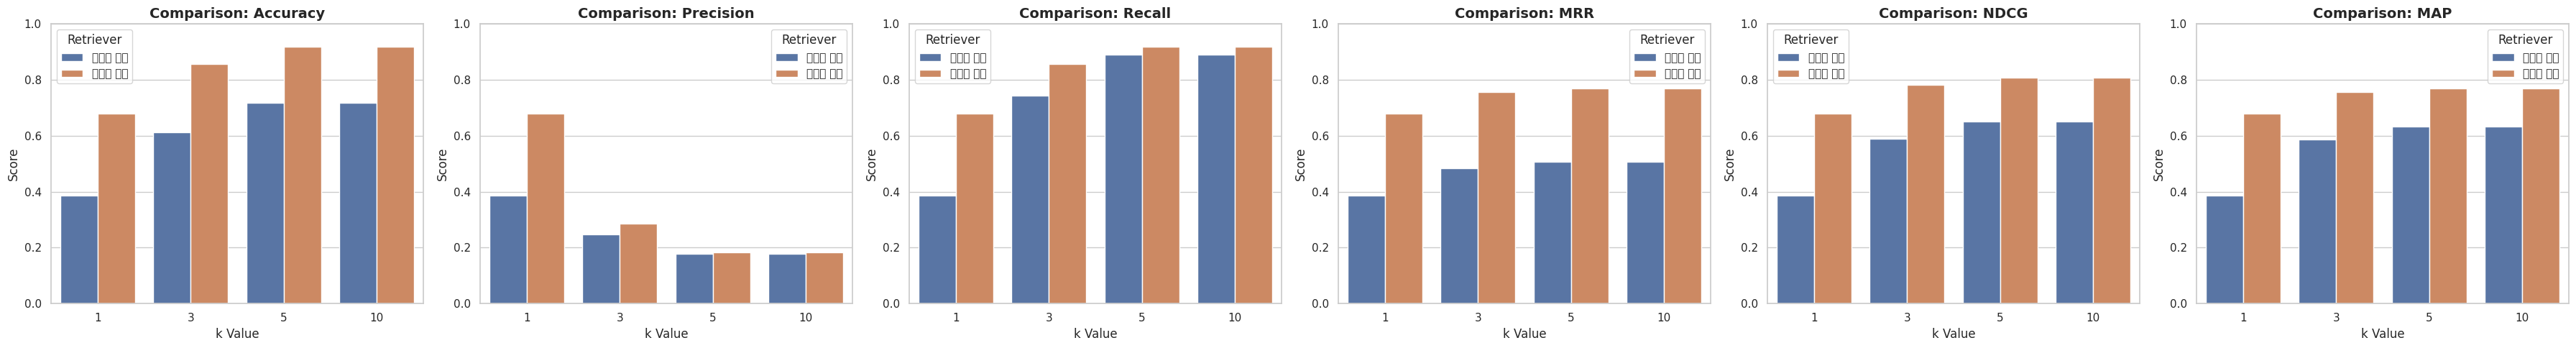

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_retriever_comparison(results_list, names):
    """
    여러 리트리버의 평가 결과를 시각화하여 비교하는 함수

    Args:
        results_list: evaluate_retriever 함수가 반환한 avg_metrics 딕셔너리 리스트
        names: 각 결과에 매칭되는 리트리버 이름 리스트 (예: ['Base', 'Improved'])
    """
    # 1. 데이터 포맷 변환 (Plotting을 위해 Long-form 데이터프레임 생성)
    data = []
    for metrics, name in zip(results_list, names):
        for metric_name, value in metrics.items():
            # 'Accuracy@1' -> 'Accuracy', '1' 분리
            metric_type, k_val = metric_name.split('@')
            data.append({
                'Retriever': name,
                'Metric': metric_type,
                'k': int(k_val),
                'Value': value
            })

    df_plot = pd.DataFrame(data)

    # 2. 시각화 설정
    sns.set_theme(style="whitegrid")
    metrics_to_show = df_plot['Metric'].unique()

    # 지표 개수에 따라 서브플롯 생성
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(6 * len(metrics_to_show), 5))
    if len(metrics_to_show) == 1: axes = [axes]

    for ax, metric in zip(axes, metrics_to_show):
        subset = df_plot[df_plot['Metric'] == metric]
        sns.barplot(data=subset, x='k', y='Value', hue='Retriever', ax=ax)
        ax.set_title(f'Comparison: {metric}', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.0) # 지표는 보통 0~1 사이
        ax.set_xlabel('k Value')
        ax.set_ylabel('Score')
        ax.legend(title='Retriever')

    plt.tight_layout()
    plt.show()

visualize_retriever_comparison([n_metrics, p_metrics], ["전처리 이전", "전처리 이후"])